Connect to T4 GPU and check if it succeeds.

In [1]:
!nvidia-smi

Mon Jun  8 14:42:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Clone the repository and install requirements. Restart session if prompted.

In [2]:
!git clone https://github.com/xl2024/Interpretable-VLM.git
%cd Interpretable-VLM
!pip install -r requirements.txt

fatal: destination path 'Interpretable-VLM' already exists and is not an empty directory.
/content/Interpretable-VLM
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121


Re-enter the project directory if necessary.

In [3]:
%cd Interpretable-VLM

[Errno 2] No such file or directory: 'Interpretable-VLM'
/content/Interpretable-VLM


Replace `pca_1b` with a filename to run experiments. Note that it may take a few minutes to hours to run.

Available filenames: `pca_1b`, `rsa_1c`, `cma_1d`, `rsa_2`, `cma_3`, `cma_4`, `cma_4_v2`, `cma_5`, `rsa_6`, `rsa_6_v2`, `cma_29`, `cma_45`, `cma_46`, `cma_tbl_1`, `cma_tbl_1_v2`, `pca_new_26`. Check [`README.md`](https://github.com/xl2024/Interpretable-VLM/blob/main/README.md) for details.

In [3]:
# update tier to local to run 4-bit quantization of 7B models on free T4
!sed -i 's/tier: "cloud"/tier: "local"/' configs/config.yaml

In [4]:
# replace pca_1b with the filename of the script to be run
!python -m src.plots.pca_1b

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
=== Figure 1b Reproduction: PCA ===
Initializing Load Sequence for: Qwen/Qwen2-VL-7B-Instruct on local...
Local Notice: Local CUDA detected. Using 4-bit quantization.
Loading processor...
preprocessor_config.json: 100% 347/347 [00:00<00:00, 1.50MB/s]
chat_template.json: 100% 1.05k/1.05k [00:00<00:00, 3.45MB/s]
config.json: 100% 1.20k/1.20k [00:00<00:00, 5.02MB/s]
tokenizer_config.json: 100% 4.19k/4.19k [00:00<00:00, 11.1MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 17.6MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 110MB/s]
tokenizer.json: 100% 7.03M/7.03M [00:00<00:00, 147MB/s]
Loading and tracing model weights with torch.float16...
model.safetensors.index.json: 100% 56.5k/56.5k [00:00<0

Copy and paste the save path for the generated `.png` file from the output of the last cell.

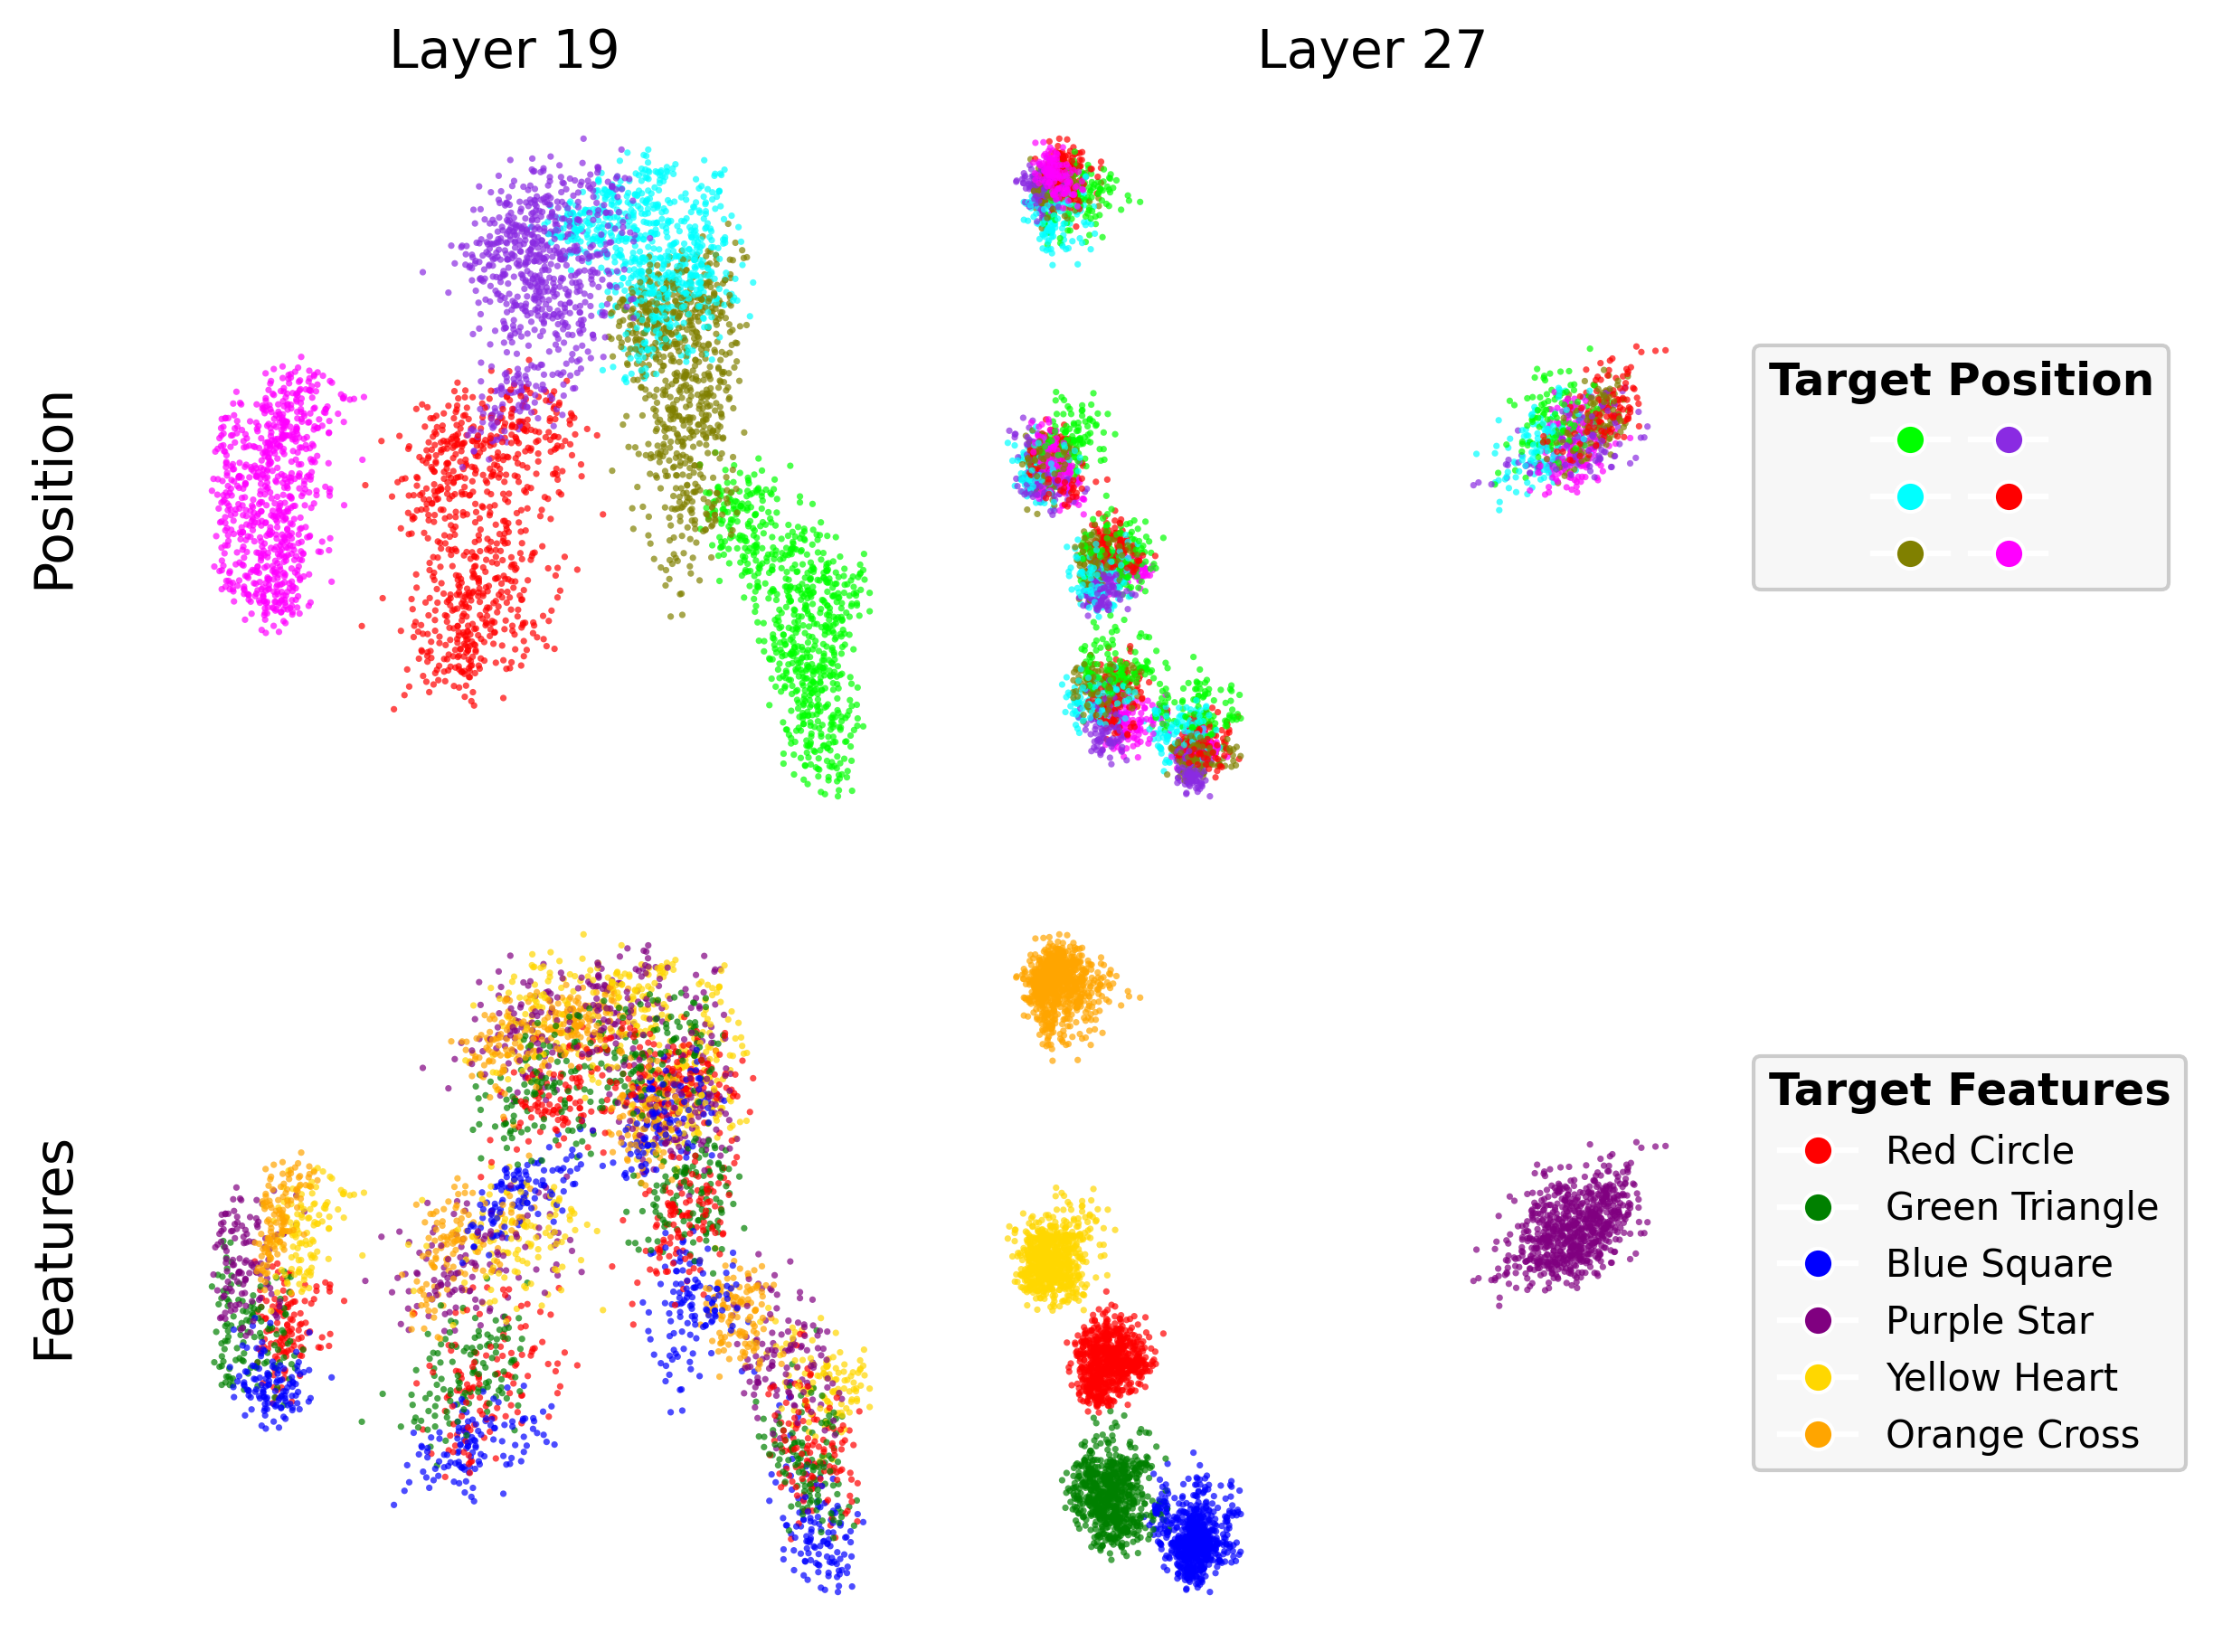

In [5]:
from IPython.display import Image, display
filename='outputs/pca/pca_fig_1b.png'
display(Image(filename=filename))

Run the cell below to view `.md` file if one was generated.

In [6]:
# cma_tbl_1.py reproduces Table 1 in the paper
!python -m src.plots.cma_tbl_1

from IPython.display import display, Markdown

file_path = "outputs/cma/entr/cma_tbl_1.md"
with open(file_path, "r") as file:
    markdown_content = file.read()

display(Markdown(markdown_content))

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Found src/data/cma/entr/llava-hf_llava-1.5-7b-hf.json! Loading results for entropy intervention...
Found src/data/cma/entr/llava-hf_llava-1.5-13b-hf.json! Loading results for entropy intervention...
Found src/data/cma/entr/Qwen_Qwen2.5-VL-3B-Instruct.json! Loading results for entropy intervention...
Found src/data/cma/entr/Qwen_Qwen2.5-VL-7B-Instruct.json! Loading results for entropy intervention...
Found src/data/cma/entr/Qwen_Qwen2-VL-7B-Instruct.json! Loading results for entropy intervention...
CSV table saved to 'outputs/cma/entr/cma_tbl_1.csv'
Markdown table saved to 'outputs/cma/entr/cma_tbl_1.md'


| Model          | High Entropy   | Low Entropy (No Intervention)   | Low Entropy (With Intervention)   | Improvement   |
|:---------------|:---------------|:--------------------------------|:----------------------------------|:--------------|
| LLaVA 1.5 7B   | 66.57\%        | 44.54\%                         | 48.69\%                           | 4.15\%        |
| LLaVA 1.5 13B  | 76.32\%        | 70.47\%                         | 78.15\%                           | 7.68\%        |
| Qwen 2.5-VL 3B | 98.99\%        | 92.89\%                         | 92.64\%                           | -0.25\%       |
| Qwen 2.5-VL 7B | 97.90\%        | 95.53\%                         | 98.99\%                           | 3.46\%        |
| Qwen 2-VL 7B   | 99.83\%        | 94.07\%                         | 91.14\%                           | -2.94\%       |